# Pronóstico de Inflación Subyacente en México con ARIMA

## Objetivo
Construir un modelo ARIMA para pronosticar la inflación subyacente mensual en México,
utilizando datos históricos del Sistema de Información Económica (SIE) del Banco de México.

## Justificación
La inflación subyacente excluye los componentes volátiles del INPC (energéticos y 
agropecuarios), por lo que refleja las presiones de demanda estructurales de la economía 
y es el indicador de referencia para las decisiones de política monetaria del Banxico.
Un modelo ARIMA es apropiado porque la serie presenta autocorrelación significativa 
y una dinámica de persistencia consistente con procesos autorregresivos.

## Fuente de datos
Banco de México — SIE, Serie SF43783 (Índice de precios subyacente, variación mensual)

## Herramientas
Python · pandas · statsmodels · matplotlib · plotly

In [1]:
# --- Librerías ---
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficas
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Librerías cargadas correctamente ✓")

Librerías cargadas correctamente ✓


## 1. Obtención de datos

Conectamos directamente a la API del SIE de Banxico para descargar la serie de 
inflación subyacente mensual (SF43783). Esta serie representa la variación mensual 
del índice de precios subyacente, que excluye energéticos y agropecuarios.

Para replicar este notebook se requiere un token de acceso gratuito del SIE Banxico,
disponible en: https://www.banxico.org.mx/SieAPIRest/service/v1/

In [4]:
# --- Conexión a la API del SIE Banxico ---
TOKEN = "4fa7f18578436202fb8a51db8c973e6de62f0b51c296600d2b9216f4f5af8d7f"

# SP74660: Inflación subyacente mensual (%) — fuente directa INEGI/Banxico
SERIE = "SP74660"
URL = f"https://www.banxico.org.mx/SieAPIRest/service/v1/series/{SERIE}/datos"

headers = {"Bmx-Token": TOKEN}
response = requests.get(URL, headers=headers)
data = response.json()

# Convertir a DataFrame
registros = data["bmx"]["series"][0]["datos"]
df = pd.DataFrame(registros)
df.columns = ["fecha", "inflacion"]
df["fecha"] = pd.to_datetime(df["fecha"], format="%d/%m/%Y")
df["inflacion"] = pd.to_numeric(df["inflacion"], errors="coerce")
df = df.dropna().set_index("fecha").sort_index()

print(f"Serie cargada: {len(df)} observaciones")
print(f"Periodo: {df.index[0].strftime('%b %Y')} — {df.index[-1].strftime('%b %Y')}")
print(f"\nEstadísticas:")
print(df["inflacion"].describe().round(4))
df.tail()

Serie cargada: 531 observaciones
Periodo: Feb 1982 — Apr 2026

Estadísticas:
count    531.0000
mean       1.4152
std        2.0852
min       -0.0800
25%        0.2900
50%        0.4800
75%        1.3850
max       13.2100
Name: inflacion, dtype: float64


,inflacion
fecha,
2025-12-01,0.41
2026-01-01,0.60
2026-02-01,0.46
2026-03-01,0.38
2026-04-01,0.31


## 2. Análisis exploratorio

Visualizamos la serie histórica para identificar tendencia, 
estacionalidad y periodos de volatilidad antes de modelar.

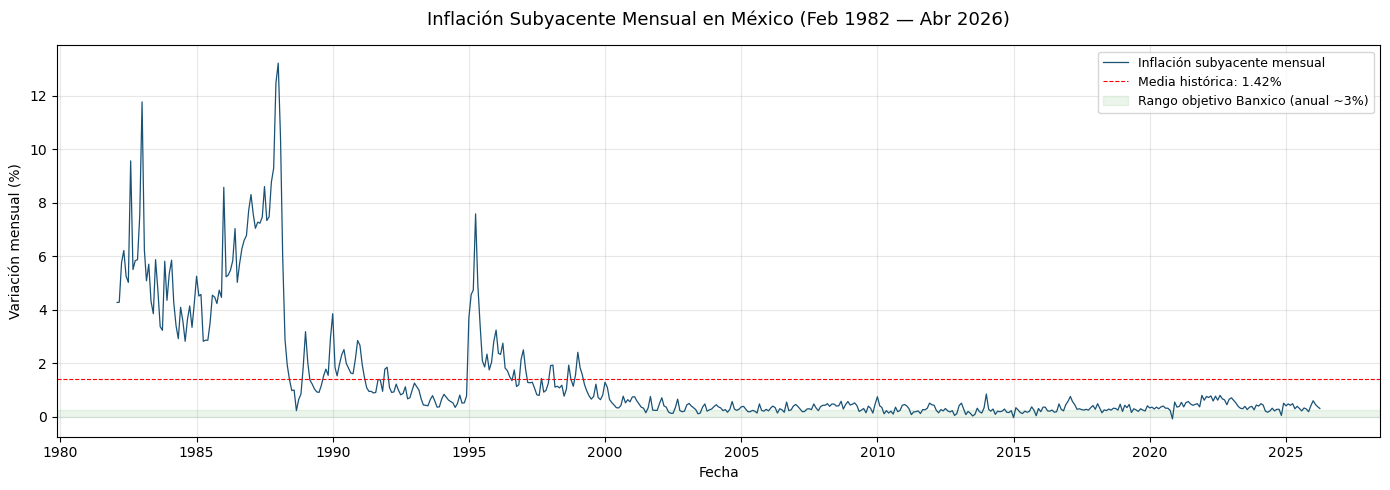

Gráfica guardada como serie_historica.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df["inflacion"], color="#1a5276", linewidth=0.9, label="Inflación subyacente mensual")
ax.axhline(y=df["inflacion"].mean(), color="red", linestyle="--", linewidth=0.8, label=f"Media histórica: {df['inflacion'].mean():.2f}%")
ax.axhspan(0, 0.25, alpha=0.08, color="green", label="Rango objetivo Banxico (anual ~3%)")

ax.set_title("Inflación Subyacente Mensual en México (Feb 1982 — Abr 2026)", fontsize=13, pad=15)
ax.set_xlabel("Fecha")
ax.set_ylabel("Variación mensual (%)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))

plt.tight_layout()
plt.savefig("serie_historica.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gráfica guardada como serie_historica.png")

In [7]:
# Filtramos desde 2000 — régimen de inflation targeting de Banxico
df_modelo = df[df.index >= "2000-01-01"].copy()

print(f"Observaciones para el modelo: {len(df_modelo)}")
print(f"Periodo: {df_modelo.index[0].strftime('%b %Y')} — {df_modelo.index[-1].strftime('%b %Y')}")
print(f"\nEstadísticas del periodo moderno:")
print(df_modelo["inflacion"].describe().round(4))

Observaciones para el modelo: 316
Periodo: Jan 2000 — Apr 2026

Estadísticas del periodo moderno:
count    316.0000
mean       0.3485
std        0.1772
min       -0.0800
25%        0.2275
50%        0.3200
75%        0.4400
max        1.2900
Name: inflacion, dtype: float64


## 3. Prueba de estacionariedad (ADF)

Antes de estimar ARIMA verificamos si la serie es estacionaria mediante 
la prueba Augmented Dickey-Fuller (ADF). 

- H0: la serie tiene raíz unitaria (no es estacionaria)
- H1: la serie es estacionaria

Si el p-valor < 0.05 rechazamos H0 y concluimos que la serie es estacionaria (d=0).

In [8]:
resultado_adf = adfuller(df_modelo["inflacion"], autolag="AIC")

print("=== Prueba Augmented Dickey-Fuller ===")
print(f"Estadístico ADF:  {resultado_adf[0]:.4f}")
print(f"P-valor:          {resultado_adf[1]:.4f}")
print(f"Rezagos usados:   {resultado_adf[2]}")
print(f"Observaciones:    {resultado_adf[3]}")
print(f"\nValores críticos:")
for nivel, valor in resultado_adf[4].items():
    print(f"  {nivel}: {valor:.4f}")

print("\n--- Conclusión ---")
if resultado_adf[1] < 0.05:
    print("✓ P-valor < 0.05 → Rechazamos H0")
    print("✓ La serie ES estacionaria → d = 0")
else:
    print("✗ P-valor ≥ 0.05 → No rechazamos H0")
    print("✗ La serie NO es estacionaria → se requiere diferenciar (d = 1)")

=== Prueba Augmented Dickey-Fuller ===
Estadístico ADF:  -3.6057
P-valor:          0.0057
Rezagos usados:   15
Observaciones:    300

Valores críticos:
  1%: -3.4523
  5%: -2.8712
  10%: -2.5719

--- Conclusión ---
✓ P-valor < 0.05 → Rechazamos H0
✓ La serie ES estacionaria → d = 0


## 4. Identificación del orden: ACF y PACF

- **PACF** → determina p (componente AR): observamos cuántos rezagos son significativos
- **ACF** → determina q (componente MA): observamos el patrón de autocorrelación

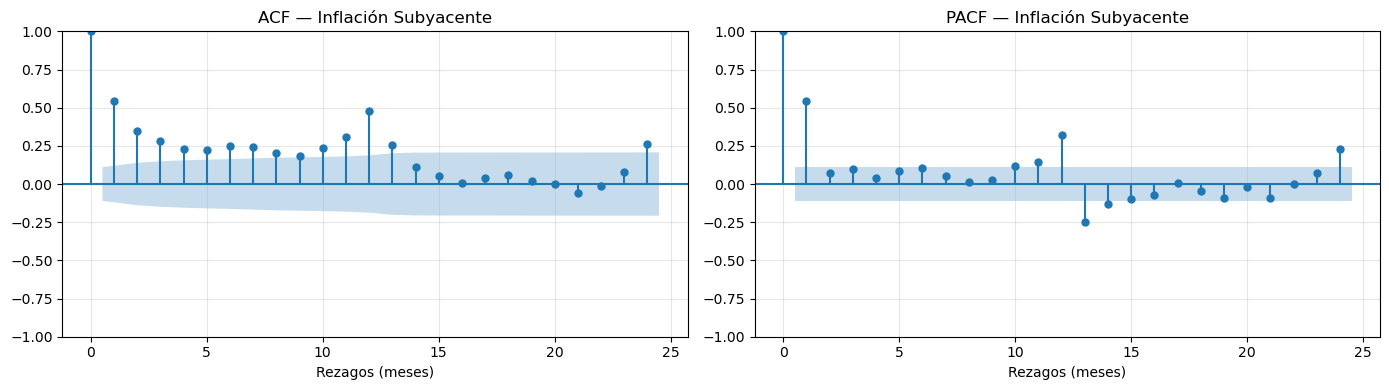

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df_modelo["inflacion"], lags=24, ax=axes[0], title="ACF — Inflación Subyacente")
plot_pacf(df_modelo["inflacion"], lags=24, ax=axes[1], title="PACF — Inflación Subyacente")

axes[0].set_xlabel("Rezagos (meses)")
axes[1].set_xlabel("Rezagos (meses)")

plt.tight_layout()
plt.savefig("acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Estimación del modelo ARIMA

Comparamos varios órdenes candidatos y seleccionamos el modelo 
con menor AIC (Akaike Information Criterion).

In [10]:
from itertools import product

# Candidatos basados en ACF y PACF
p_vals = [0, 1, 2]
q_vals = [0, 1, 2]
d = 0

resultados = []

for p, q in product(p_vals, q_vals):
    try:
        modelo = ARIMA(df_modelo["inflacion"], order=(p, d, q))
        ajuste = modelo.fit()
        resultados.append({
            "Modelo": f"ARIMA({p},{d},{q})",
            "AIC": round(ajuste.aic, 2),
            "BIC": round(ajuste.bic, 2),
            "Log-Likelihood": round(ajuste.llf, 2)
        })
    except:
        pass

df_resultados = pd.DataFrame(resultados).sort_values("AIC").reset_index(drop=True)
print("=== Comparación de modelos por AIC ===")
print(df_resultados.to_string(index=False))
print(f"\n✓ Modelo seleccionado: {df_resultados.iloc[0]['Modelo']}")

=== Comparación de modelos por AIC ===
      Modelo     AIC     BIC  Log-Likelihood
ARIMA(2,0,1) -325.14 -306.37          167.57
ARIMA(1,0,2) -323.68 -304.91          166.84
ARIMA(2,0,2) -323.30 -300.77          167.65
ARIMA(1,0,1) -317.28 -302.26          162.64
ARIMA(2,0,0) -315.51 -300.48          161.75
ARIMA(1,0,0) -314.09 -302.82          160.04
ARIMA(0,0,2) -294.52 -279.50          151.26
ARIMA(0,0,1) -278.50 -267.23          142.25
ARIMA(0,0,0) -193.84 -186.33           98.92

✓ Modelo seleccionado: ARIMA(2,0,1)


## 6. Estimación final y diagnóstico de residuales

Estimamos ARIMA(2,0,1) y verificamos que los residuales sean 
ruido blanco — condición necesaria para que el modelo sea válido.

In [11]:
# Estimación del modelo seleccionado
modelo_final = ARIMA(df_modelo["inflacion"], order=(2, 0, 1))
ajuste_final = modelo_final.fit()

print(ajuste_final.summary())

                               SARIMAX Results                                
Dep. Variable:              inflacion   No. Observations:                  316
Model:                 ARIMA(2, 0, 1)   Log Likelihood                 167.572
Date:                Thu, 21 May 2026   AIC                           -325.144
Time:                        17:55:26   BIC                           -306.366
Sample:                    01-01-2000   HQIC                          -317.642
                         - 04-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3767      0.055      6.907      0.000       0.270       0.484
ar.L1          1.3327      0.076     17.446      0.000       1.183       1.482
ar.L2         -0.3544      0.067     -5.289      0.0

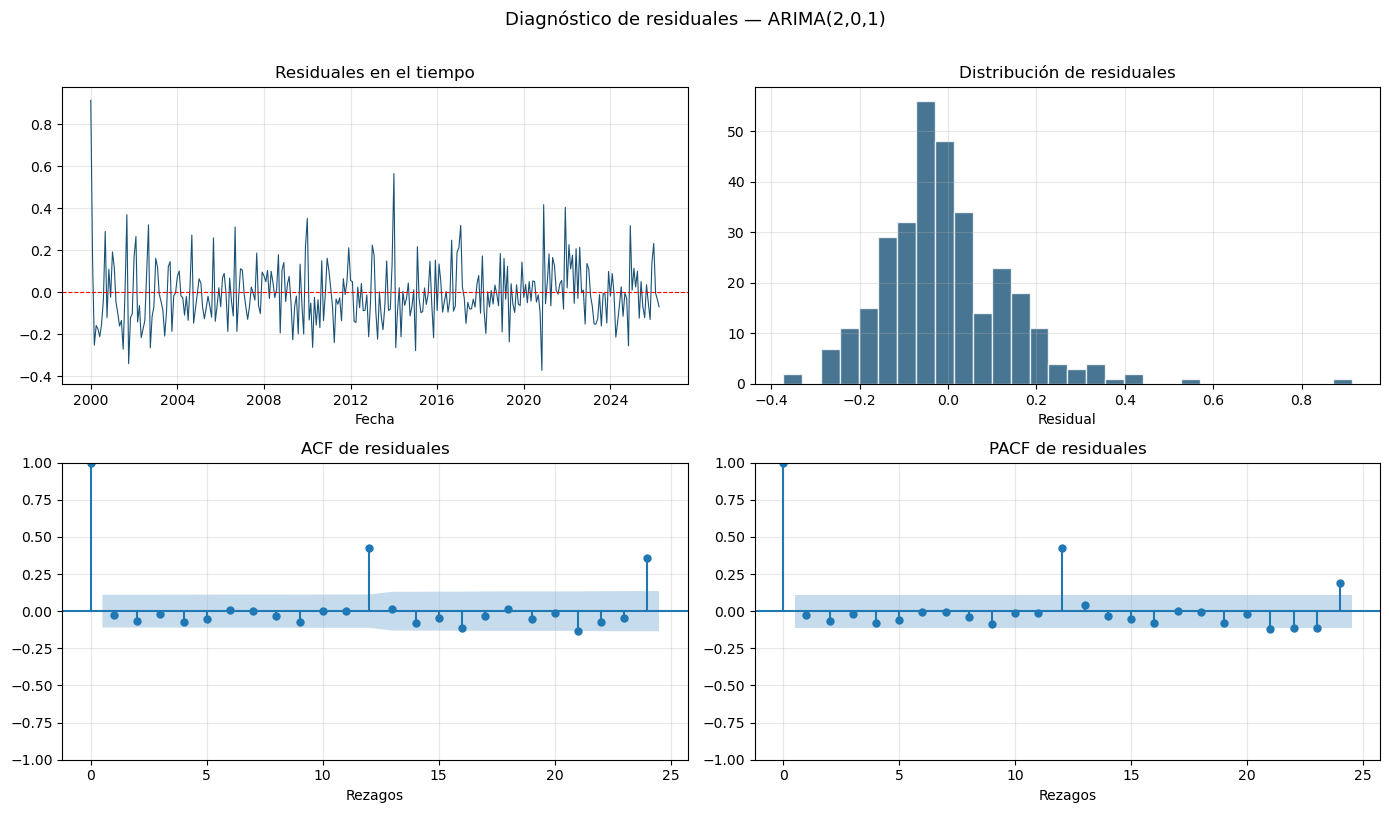

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

residuales = ajuste_final.resid

# Residuales en el tiempo
axes[0,0].plot(residuales, linewidth=0.8, color="#1a5276")
axes[0,0].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[0,0].set_title("Residuales en el tiempo")
axes[0,0].set_xlabel("Fecha")

# Histograma
axes[0,1].hist(residuales, bins=30, color="#1a5276", edgecolor="white", alpha=0.8)
axes[0,1].set_title("Distribución de residuales")
axes[0,1].set_xlabel("Residual")

# ACF de residuales
plot_acf(residuales, lags=24, ax=axes[1,0], title="ACF de residuales")
axes[1,0].set_xlabel("Rezagos")

# PACF de residuales
plot_pacf(residuales, lags=24, ax=axes[1,1], title="PACF de residuales")
axes[1,1].set_xlabel("Rezagos")

plt.suptitle("Diagnóstico de residuales — ARIMA(2,0,1)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("diagnostico_residuales.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Pronóstico a 12 meses

Generamos el pronóstico de inflación subyacente mensual para los 
próximos 12 meses con intervalos de confianza al 95%.


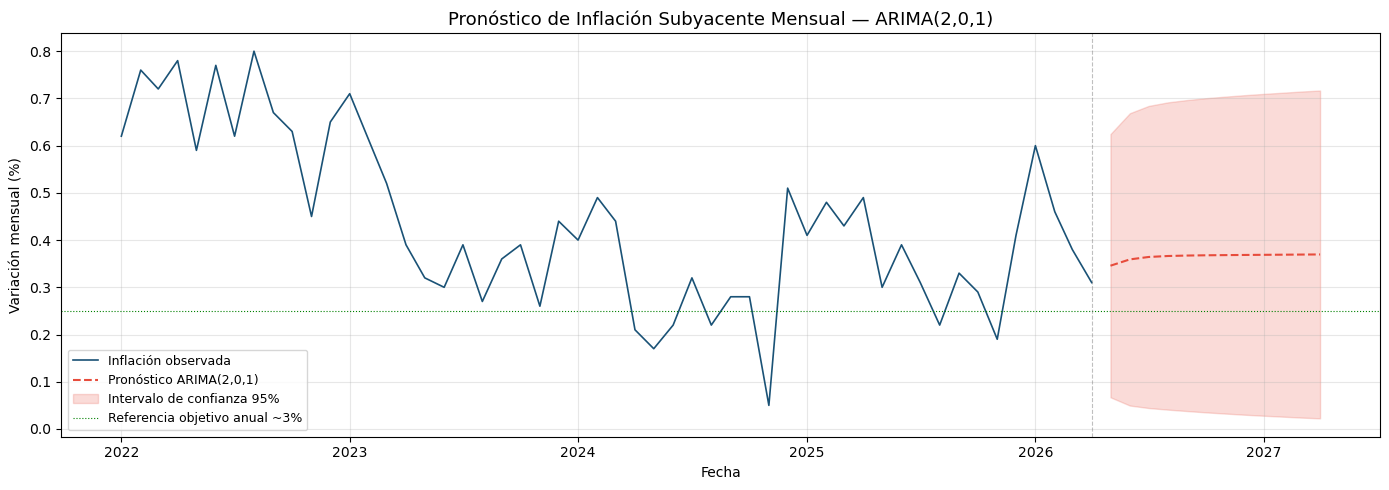


Pronóstico mensual:
inflacion     mean  mean_ci_lower  mean_ci_upper
2026-05-01  0.3458         0.0671         0.6245
2026-06-01  0.3591         0.0496         0.6686
2026-07-01  0.3642         0.0444         0.6841
2026-08-01  0.3663         0.0410         0.6917
2026-09-01  0.3673         0.0379         0.6966
2026-10-01  0.3678         0.0352         0.7005
2026-11-01  0.3682         0.0326         0.7038
2026-12-01  0.3685         0.0302         0.7068
2027-01-01  0.3688         0.0281         0.7096
2027-02-01  0.3691         0.0260         0.7121
2027-03-01  0.3693         0.0242         0.7145
2027-04-01  0.3696         0.0225         0.7167


In [13]:
# Pronóstico a 12 meses
pasos = 12
pronostico = ajuste_final.get_forecast(steps=pasos)
df_pronostico = pronostico.summary_frame(alpha=0.05)

# Índice de fechas futuras
fechas_futuras = pd.date_range(
    start=df_modelo.index[-1] + pd.DateOffset(months=1),
    periods=pasos, freq="MS"
)
df_pronostico.index = fechas_futuras

# Gráfica
fig, ax = plt.subplots(figsize=(14, 5))

# Serie histórica reciente (últimos 3 años)
df_reciente = df_modelo[df_modelo.index >= "2022-01-01"]
ax.plot(df_reciente.index, df_reciente["inflacion"],
        color="#1a5276", linewidth=1.2, label="Inflación observada")

# Pronóstico
ax.plot(df_pronostico.index, df_pronostico["mean"],
        color="#e74c3c", linewidth=1.5, linestyle="--", label="Pronóstico ARIMA(2,0,1)")

# Intervalo de confianza 95%
ax.fill_between(df_pronostico.index,
                df_pronostico["mean_ci_lower"],
                df_pronostico["mean_ci_upper"],
                alpha=0.2, color="#e74c3c", label="Intervalo de confianza 95%")

ax.axhline(y=0.25, color="green", linestyle=":", linewidth=0.8, label="Referencia objetivo anual ~3%")
ax.axvline(x=df_modelo.index[-1], color="gray", linestyle="--", linewidth=0.8, alpha=0.5)

ax.set_title("Pronóstico de Inflación Subyacente Mensual — ARIMA(2,0,1)", fontsize=13)
ax.set_xlabel("Fecha")
ax.set_ylabel("Variación mensual (%)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("pronostico.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nPronóstico mensual:")
print(df_pronostico[["mean", "mean_ci_lower", "mean_ci_upper"]].round(4))

## 8. Evaluación out-of-sample

Dividimos la serie en entrenamiento (2000-2022) y prueba (2023-2026)
para evaluar qué tan bien predice el modelo datos que no vio durante 
la estimación. Calculamos RMSE y MAE como métricas de error.

=== Evaluación out-of-sample (Ene 2023 — Abr 2026) ===
RMSE: 0.1141%
MAE:  0.0946%

Interpretación: el modelo se equivoca en promedio 0.095 puntos
porcentuales por mes en el periodo de prueba.


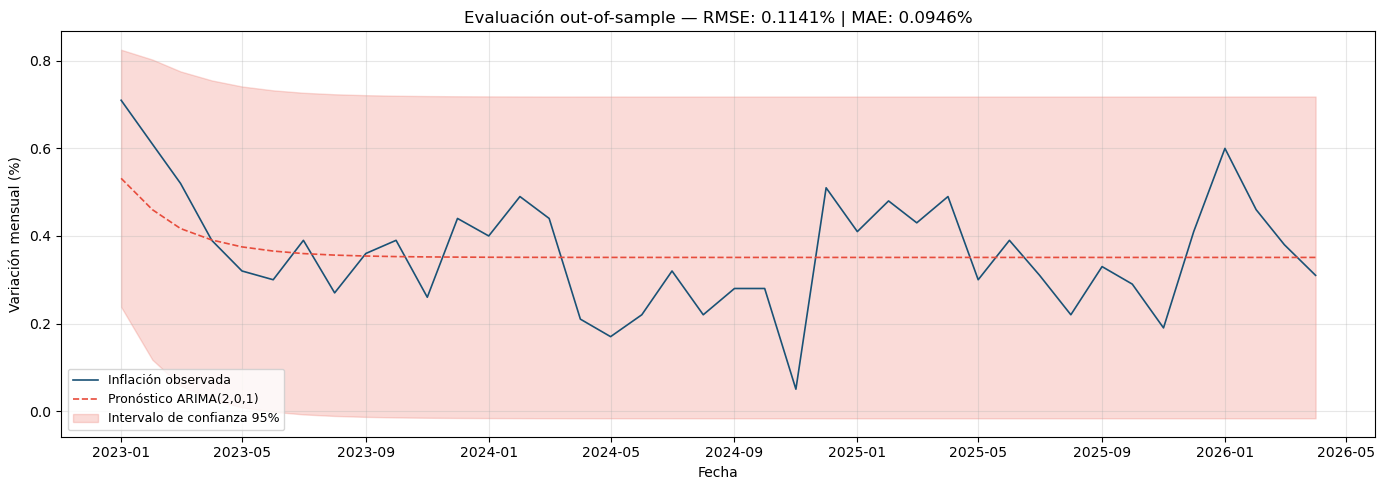

In [14]:
import numpy as np

# División entrenamiento / prueba
train = df_modelo[df_modelo.index < "2023-01-01"]
test = df_modelo[df_modelo.index >= "2023-01-01"]

# Reentrenar con datos de entrenamiento
modelo_train = ARIMA(train["inflacion"], order=(2, 0, 1))
ajuste_train = modelo_train.fit()

# Pronóstico para el periodo de prueba
pronostico_test = ajuste_train.get_forecast(steps=len(test))
df_test = pronostico_test.summary_frame(alpha=0.05)
df_test.index = test.index

# Métricas
rmse = np.sqrt(((test["inflacion"] - df_test["mean"]) ** 2).mean())
mae = (test["inflacion"] - df_test["mean"]).abs().mean()

print(f"=== Evaluación out-of-sample (Ene 2023 — Abr 2026) ===")
print(f"RMSE: {rmse:.4f}%")
print(f"MAE:  {mae:.4f}%")
print(f"\nInterpretación: el modelo se equivoca en promedio {mae:.3f} puntos")
print(f"porcentuales por mes en el periodo de prueba.")

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(test.index, test["inflacion"],
        color="#1a5276", linewidth=1.2, label="Inflación observada")
ax.plot(df_test.index, df_test["mean"],
        color="#e74c3c", linewidth=1.2, linestyle="--", label="Pronóstico ARIMA(2,0,1)")
ax.fill_between(df_test.index,
                df_test["mean_ci_lower"],
                df_test["mean_ci_upper"],
                alpha=0.2, color="#e74c3c", label="Intervalo de confianza 95%")

ax.set_title(f"Evaluación out-of-sample — RMSE: {rmse:.4f}% | MAE: {mae:.4f}%", fontsize=12)
ax.set_xlabel("Fecha")
ax.set_ylabel("Variación mensual (%)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("evaluacion_out_of_sample.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Inflación anual implícita en el pronóstico

Una vez obtenidas las variaciones mensuales proyectadas, podemos reconstruir 
el índice de precios subyacente hacia adelante y calcular la inflación anual 
implícita, que es el indicador de referencia pública que publica el INEGI 
mensualmente.

La metodología es:
1. Tomar el último índice conocido (abril 2026)
2. Aplicar sucesivamente cada variación mensual pronosticada
3. Comparar cada índice proyectado contra el mismo mes del año anterior

Esto permite traducir el pronóstico técnico del modelo a una métrica 
directamente comparable con el objetivo de inflación de Banxico (3% ± 1pp).

In [17]:
# Reconstruimos índice base desde df (variaciones mensuales)
# Tomamos base 100 en enero 2000 y acumulamos
df_idx_rec = df_modelo.copy()
df_idx_rec["indice_rec"] = 100 * (1 + df_idx_rec["inflacion"]/100).cumprod()

# Último índice reconstruido
indice_actual = df_idx_rec["indice_rec"].iloc[-1]
fecha_actual = df_idx_rec.index[-1]
print(f"Último índice reconstruido: {indice_actual:.4f} ({fecha_actual.strftime('%b %Y')})")

# Proyectamos el índice con los pronósticos
indices_proyectados = [indice_actual]
for var in df_pronostico["mean"].values:
    nuevo_indice = indices_proyectados[-1] * (1 + var/100)
    indices_proyectados.append(nuevo_indice)

fechas_proj = pd.date_range(
    start=fecha_actual, periods=len(df_pronostico)+1, freq="MS"
)
df_indices_proj = pd.DataFrame({
    "indice_proyectado": indices_proyectados
}, index=fechas_proj)

# Inflación anual implícita
print("\nInflación anual implícita en el pronóstico:")
print(f"{'Fecha':<12} {'Índice proy.':<15} {'Índice hace 12m':<18} {'Inflación anual'}")
print("-" * 58)

for fecha, row in df_indices_proj.iloc[1:].iterrows():
    fecha_hace_12m = fecha - pd.DateOffset(months=12)
    if fecha_hace_12m in df_idx_rec.index:
        indice_12m = df_idx_rec.loc[fecha_hace_12m, "indice_rec"]
        inflacion_anual = (row["indice_proyectado"] / indice_12m - 1) * 100
        print(f"{fecha.strftime('%b %Y'):<12} {row['indice_proyectado']:<15.4f} {indice_12m:<18.4f} {inflacion_anual:.2f}%")

Último índice reconstruido: 300.0549 (Apr 2026)

Inflación anual implícita en el pronóstico:
Fecha        Índice proy.    Índice hace 12m    Inflación anual
----------------------------------------------------------
May 2026     301.0924        288.6285           4.32%
Jun 2026     302.1737        289.7542           4.29%
Jul 2026     303.2743        290.6524           4.34%
Aug 2026     304.3852        291.2918           4.49%
Sep 2026     305.5031        292.2531           4.53%
Oct 2026     306.6268        293.1006           4.61%
Nov 2026     307.7558        293.6575           4.80%
Dec 2026     308.8899        294.8615           4.76%
Jan 2027     310.0291        296.6307           4.52%
Feb 2027     311.1734        297.9952           4.42%
Mar 2027     312.3227        299.1276           4.41%
Apr 2027     313.4770        300.0549           4.47%


## 9. Conclusiones

**Modelo estimado:** ARIMA(2, 0, 1)

**Hallazgos principales:**

- La inflación subyacente mensual en México es estacionaria en el periodo 
  2000-2026 (prueba ADF: p=0.0057), lo que refleja que el esquema de objetivos 
  de inflación de Banxico ha anclado efectivamente las expectativas de precios 
  en el régimen moderno.

- El modelo ARIMA(2,0,1) fue seleccionado por criterio AIC entre 9 
  especificaciones candidatas. Todos sus coeficientes son estadísticamente 
  significativos (p<0.001), y los residuales se comportan como ruido blanco 
  (Ljung-Box p=0.55), confirmando que el modelo capturó adecuadamente la 
  estructura de autocorrelación de la serie.

- La evaluación out-of-sample (Ene 2023 — Abr 2026) arrojó un RMSE de 0.1141% 
  y un MAE de 0.0946%, lo que equivale a un error promedio menor a una cuarta 
  parte de la variación mensual típica de la serie. Para un modelo univariado 
  sin variables macroeconómicas adicionales, este resultado constituye un 
  benchmark sólido.

**Pronóstico:**

El modelo proyecta una inflación subyacente mensual de ~0.35-0.37% para los 
próximos 12 meses, equivalente a una tasa anual implícita de entre 4.3% y 4.8%, 
con un pico en octubre-noviembre 2026 explicado por un efecto base favorable, 
y una convergencia posterior hacia ~4.4% hacia abril 2027.

**Limitaciones y extensiones:**

- El modelo es univariado: no incorpora variables como tasa de interés (TIIE), 
  tipo de cambio USD/MXN o brecha del producto, que tienen influencia documentada 
  sobre la inflación subyacente. Este ARIMA funciona como modelo benchmark; 
  una extensión natural sería un modelo VAR para evaluar si dichas variables 
  mejoran la precisión out-of-sample.

- El rezago 12 significativo en la ACF de residuales sugiere un patrón 
  estacional anual no capturado completamente. Un modelo SARIMA con componente 
  estacional explícito podría mejorar el ajuste.

- Los choques externos (decisiones de la Fed, geopolítica, precios de commodities) 
  no son predecibles por el modelo y explican los episodios de mayor error 
  en el periodo de prueba.